# 5 — Visualización orientada a preguntas

Un gráfico no es el objetivo: es evidencia para responder una pregunta. En cada ejercicio primero escribí qué querés averiguar, luego construí la agregación y finalmente redactá una conclusión de dos o tres oraciones.

Este notebook se ejecuta manualmente **después** de que el Job termina correctamente; no forma parte del pipeline.

In [0]:
dbutils.widgets.text("student_id", "alumno01", "01 - Identificador")
dbutils.widgets.dropdown("scale", "small", ["test", "small", "demo"], "02 - Escala")

In [0]:
%run ../common/config

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

catalog = spark.sql("SELECT current_catalog()").first()[0]
config = CourseConfig(catalog, dbutils.widgets.get("student_id"), dbutils.widgets.get("scale"))
daily = qualified_table(config, "gold_daily_sales")
risk = qualified_table(config, "gold_customer_risk")
batch = qualified_table(config, "gold_batch_summary")
for table in [daily, risk, batch]:
    assert spark.catalog.tableExists(table), f"Falta {table}. Ejecutá primero el Job completo."

## Ejemplo resuelto

**Pregunta:** ¿Qué categoría concentra el mayor monto vendido?

La agregación se hace con Spark. Sólo el resultado pequeño se convierte a Pandas para dibujarlo. Un gráfico de barras ordenado permite comparar categorías; un gráfico de torta haría más difícil comparar valores cercanos.

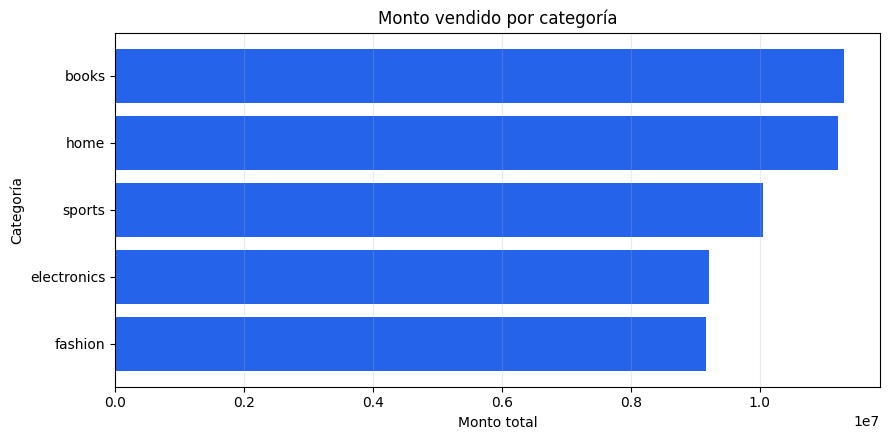

Respuesta: books es la categoría con mayor monto vendido (11,301,216.09).


In [0]:
category_sales = (spark.table(daily)
    .groupBy("category")
    .agg(F.sum("total_amount").alias("total_amount"))
    .orderBy(F.desc("total_amount")))

plot_data = category_sales.toPandas().sort_values("total_amount")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(plot_data["category"], plot_data["total_amount"], color="#2563eb")
ax.set_title("Monto vendido por categoría")
ax.set_xlabel("Monto total")
ax.set_ylabel("Categoría")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

leader = category_sales.first()
print(f"Respuesta: {leader.category} es la categoría con mayor monto vendido ({leader.total_amount:,.2f}).")

## Consigna 1 — Evolución temporal

**Pregunta:** ¿Qué día tuvo el mayor monto vendido y ese día también fue el de mayor cantidad de transacciones?

Construí una visualización temporal que permita comparar ambas métricas sin ocultar sus unidades. Explicá si los dos máximos coinciden y qué implica que coincidan —o no— sobre el ticket promedio. Fuente sugerida: `gold_daily_sales`.

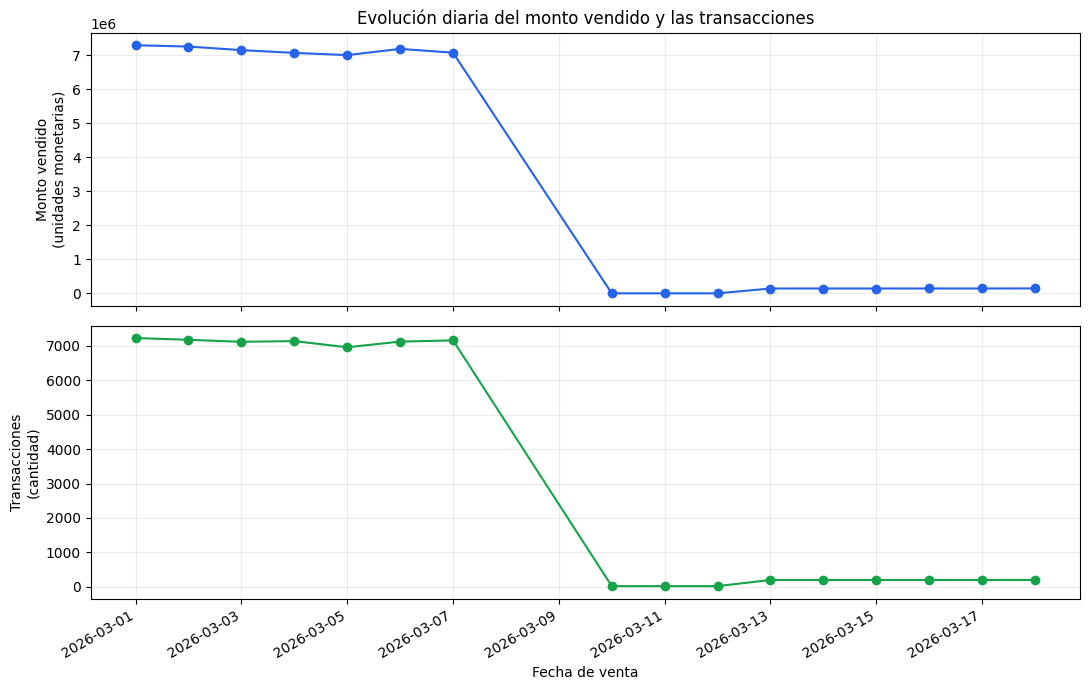

Mayor monto vendido: 7,298,974.49 unidades monetarias el día o los días 2026-03-01.
Mayor cantidad de transacciones: 7,225 el día o los días 2026-03-01.
Los máximos coinciden en 2026-03-01. Ese día se alcanzaron tanto el mayor monto como la mayor cantidad de operaciones. Esto no implica que el ticket promedio haya sido el más alto.

Ticket promedio en los días de máximo monto o cantidad:


sale_date,monto_total,transacciones,ticket_promedio
2026-03-01,7298974.49,7225,1010.238683737024


In [0]:
# Tu solución. Agregá por sale_date antes de convertir el resultado a Pandas.

# Agregar con Spark antes de convertir a Pandas.
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# Agregar con Spark antes de convertir a Pandas.
daily_totals = (
    spark.table(daily)
    .groupBy("sale_date")
    .agg(
        F.sum("total_amount").alias("monto_total"),
        F.sum("transaction_count").alias("transacciones")
    )
    .withColumn(
        "ticket_promedio",
        F.when(
            F.col("transacciones") > 0,
            F.col("monto_total") / F.col("transacciones")
        )
    )
    .orderBy("sale_date")
)

assert daily_totals.count() > 0, "La tabla Gold no contiene datos."

# Sólo el resultado agregado se convierte a Pandas.
plot_data = daily_totals.toPandas()
plot_data["monto_total"] = plot_data["monto_total"].astype(float)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(
    plot_data["sale_date"],
    plot_data["monto_total"],
    marker="o",
    color="#2563eb"
)
axes[0].set_title("Evolución diaria del monto vendido y las transacciones")
axes[0].set_ylabel("Monto vendido\n(unidades monetarias)")
axes[0].grid(alpha=0.25)

axes[1].plot(
    plot_data["sale_date"],
    plot_data["transacciones"],
    marker="o",
    color="#16a34a"
)
axes[1].set_ylabel("Transacciones\n(cantidad)")
axes[1].set_xlabel("Fecha de venta")
axes[1].grid(alpha=0.25)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

# Identificar máximos, incluyendo posibles empates.
max_monto = plot_data["monto_total"].max()
max_transacciones = plot_data["transacciones"].max()

dias_monto = set(
    plot_data.loc[
        plot_data["monto_total"] == max_monto, "sale_date"
    ]
)
dias_transacciones = set(
    plot_data.loc[
        plot_data["transacciones"] == max_transacciones, "sale_date"
    ]
)

def fechas(dias):
    return ", ".join(str(dia) for dia in sorted(dias))

print(
    f"Mayor monto vendido: {max_monto:,.2f} unidades monetarias "
    f"el día o los días {fechas(dias_monto)}."
)
print(
    f"Mayor cantidad de transacciones: {max_transacciones:,.0f} "
    f"el día o los días {fechas(dias_transacciones)}."
)

coinciden = dias_monto & dias_transacciones

if coinciden:
    print(
        f"Los máximos coinciden en {fechas(coinciden)}. "
        "Ese día se alcanzaron tanto el mayor monto como la mayor "
        "cantidad de operaciones. Esto no implica que el ticket "
        "promedio haya sido el más alto."
    )
else:
    print(
        "Los máximos no coinciden. El día de mayor monto tuvo menos "
        "operaciones que el día de mayor cantidad de transacciones, "
        "pero un ticket promedio más alto: cada operación aportó, "
        "en promedio, más dinero."
    )

print("\nTicket promedio en los días de máximo monto o cantidad:")
display(
    daily_totals.where(
        (F.col("monto_total") == F.lit(max_monto)) |
        (F.col("transacciones") == F.lit(int(max_transacciones)))
    )
)



# Incluí título, ejes, unidades y una respuesta escrita.

## Consigna 2 — Canal y fraude

**Pregunta:** ¿Qué canal de pago presenta la mayor tasa de fraude? ¿La conclusión se sostiene al considerar el número de transacciones de cada canal?

Mostrá tasa y volumen de manera legible. No compares sólo cantidades de fraude: calculá el denominador correcto. Fuente sugerida: `gold_daily_sales`.

payment_channel,fraudes,transacciones,tasa_fraude_pct
transfer,2359,16986,13.8879076886848
wallet,2200,16988,12.950317871438662
card,2150,17172,12.520382017237363


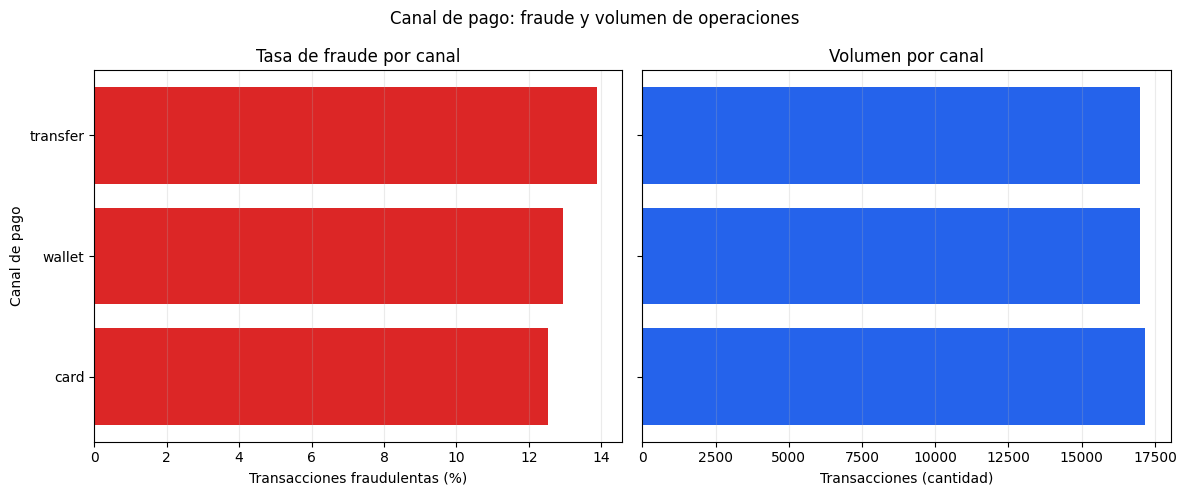

Tasa global de fraude: 13.12%.
El canal transfer presenta la mayor tasa observada: 13.89%, con 2,359 fraudes sobre 16,986 transacciones (33.2% del volumen total).

La tasa permite comparar canales considerando su volumen. Sin embargo, si el canal líder tiene pocas transacciones, su tasa es más sensible a unos pocos casos y la conclusión es menos sólida. Un volumen elevado aporta más evidencia, aunque estos gráficos por sí solos no demuestran que la diferencia entre canales sea estadísticamente significativa.


In [0]:
# Tu solución. Recalculá la tasa global como suma(fraud_transactions) / suma(transaction_count).
# Evitá promediar directamente fraud_rate entre grupos.

from pyspark.sql import functions as F
import matplotlib.pyplot as plt

gold = spark.table(daily)

# Identificar el nombre de la columna de canal.
channel_col = next(
    (c for c in ["payment_channel", "channel", "payment_method"]
     if c in gold.columns),
    None
)

assert channel_col is not None, (
    f"No se encontró la columna de canal. Columnas: {gold.columns}"
)

# Agregar con Spark: no promediar fraud_rate.
channel_metrics = (
    gold.groupBy(channel_col)
    .agg(
        F.sum("fraud_transactions").alias("fraudes"),
        F.sum("transaction_count").alias("transacciones")
    )
    .where(F.col("transacciones") > 0)
    .withColumn(
        "tasa_fraude_pct",
        100.0 * F.col("fraudes") / F.col("transacciones")
    )
    .orderBy(F.desc("tasa_fraude_pct"), F.desc("transacciones"))
)

display(channel_metrics)

# Convertir únicamente el resultado agregado.
plot_data = channel_metrics.toPandas()
assert not plot_data.empty, "No hay transacciones para analizar."

plot_data["tasa_fraude_pct"] = (
    plot_data["tasa_fraude_pct"].astype(float)
)
labels = plot_data[channel_col].fillna("Sin canal").astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
positions = list(range(len(plot_data)))

axes[0].barh(
    positions, plot_data["tasa_fraude_pct"], color="#dc2626"
)
axes[0].set_yticks(positions)
axes[0].set_yticklabels(labels)
axes[0].invert_yaxis()
axes[0].set_title("Tasa de fraude por canal")
axes[0].set_xlabel("Transacciones fraudulentas (%)")
axes[0].set_ylabel("Canal de pago")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(
    positions, plot_data["transacciones"], color="#2563eb"
)
axes[1].set_title("Volumen por canal")
axes[1].set_xlabel("Transacciones (cantidad)")
axes[1].grid(axis="x", alpha=0.25)

fig.suptitle("Canal de pago: fraude y volumen de operaciones")
fig.tight_layout()
plt.show()

# Tasa global: suma de fraudes / suma de transacciones.
totals = channel_metrics.agg(
    F.sum("fraudes").alias("fraudes"),
    F.sum("transacciones").alias("transacciones")
).first()

global_rate = 100 * totals.fraudes / totals.transacciones

max_rate = plot_data["tasa_fraude_pct"].max()
leaders = plot_data[
    plot_data["tasa_fraude_pct"] == max_rate
]

print(f"Tasa global de fraude: {global_rate:.2f}%.")

for _, row in leaders.iterrows():
    share = 100 * row["transacciones"] / totals.transacciones
    print(
        f"El canal {row[channel_col]} presenta la mayor tasa observada: "
        f"{row['tasa_fraude_pct']:.2f}%, con "
        f"{int(row['fraudes']):,} fraudes sobre "
        f"{int(row['transacciones']):,} transacciones "
        f"({share:.1f}% del volumen total)."
    )

print(
    "\nLa tasa permite comparar canales considerando su volumen. "
    "Sin embargo, si el canal líder tiene pocas transacciones, "
    "su tasa es más sensible a unos pocos casos y la conclusión "
    "es menos sólida. Un volumen elevado aporta más evidencia, "
    "aunque estos gráficos por sí solos no demuestran que la "
    "diferencia entre canales sea estadísticamente significativa."
)

## Consigna 3 — Concentración geográfica y de producto

**Pregunta:** ¿Qué combinación de país y categoría genera el mayor monto? ¿Existe una categoría dominante en todos los países o cambia según el mercado?

Elegí una visualización que permita comparar simultáneamente países y categorías. Justificá brevemente por qué ese tipo de gráfico es adecuado. Fuente sugerida: `gold_daily_sales`.

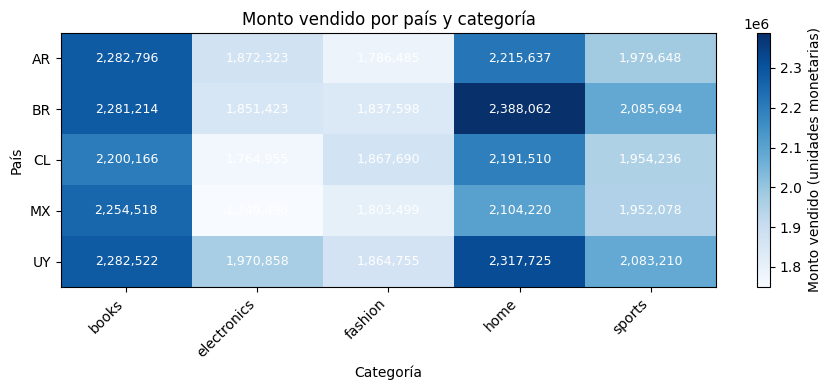

MÁXIMO GLOBAL
BR — home: 2,388,062.02 unidades monetarias.

CATEGORÍAS LÍDERES POR PAÍS
AR: books (2,282,795.70 unidades monetarias).
BR: home (2,388,062.02 unidades monetarias).
CL: books (2,200,165.90 unidades monetarias).
MX: books (2,254,517.99 unidades monetarias).
UY: home (2,317,724.80 unidades monetarias).

CONCLUSIÓN
La categoría dominante cambia según el mercado: no existe una categoría que lidere en todos los países.

El mapa de calor es adecuado porque cruza países y categorías en una misma matriz y utiliza una escala de color común para comparar montos e identificar concentraciones de ventas. Las celdas vacías representan combinaciones sin registros.


In [0]:
# Tu solución. Algunas opciones: mapa de calor o barras agrupadas.
# La conclusión debe mencionar tanto el máximo global como las diferencias entre países.

from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt

# Agregar con Spark antes de convertir a Pandas.
country_category = (
    spark.table(daily)
    .groupBy("country", "category")
    .agg(F.sum("total_amount").alias("monto_total"))
)

plot_data = country_category.toPandas()
assert not plot_data.empty, "No hay datos para analizar."

plot_data["monto_total"] = plot_data["monto_total"].astype(float)
plot_data["country"] = plot_data["country"].fillna("Sin país")
plot_data["category"] = plot_data["category"].fillna("Sin categoría")

matrix = plot_data.pivot_table(
    index="country",
    columns="category",
    values="monto_total",
    aggfunc="sum"
).sort_index()

# Los pares sin registros quedan vacíos, no se interpretan como cero.
fig, ax = plt.subplots(
    figsize=(max(9, len(matrix.columns) * 1.5),
             max(4, len(matrix.index) * 0.7))
)

heatmap = ax.imshow(
    matrix.to_numpy(dtype=float),
    cmap="Blues",
    aspect="auto"
)

ax.set_xticks(range(len(matrix.columns)))
ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index)
ax.set_title("Monto vendido por país y categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("País")

fig.colorbar(
    heatmap, ax=ax,
    label="Monto vendido (unidades monetarias)"
)

# Anotar los montos para facilitar la comparación.
threshold = plot_data["monto_total"].max() / 2

for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        value = matrix.iloc[i, j]
        if pd.notna(value):
            ax.text(
                j, i, f"{value:,.0f}",
                ha="center", va="center",
                color="white" if value > threshold else "black",
                fontsize=9
            )

fig.tight_layout()
plt.show()

# Máximo global, incluyendo posibles empates.
global_max = plot_data["monto_total"].max()
global_leaders = plot_data[
    plot_data["monto_total"] == global_max
]

print("MÁXIMO GLOBAL")
for _, row in global_leaders.iterrows():
    print(
        f"{row['country']} — {row['category']}: "
        f"{row['monto_total']:,.2f} unidades monetarias."
    )

# Categorías líderes por país, incluyendo empates.
country_max = plot_data.groupby("country")["monto_total"].transform("max")
leaders = plot_data[
    plot_data["monto_total"] == country_max
].sort_values(["country", "category"])

print("\nCATEGORÍAS LÍDERES POR PAÍS")
for _, row in leaders.iterrows():
    print(
        f"{row['country']}: {row['category']} "
        f"({row['monto_total']:,.2f} unidades monetarias)."
    )

leader_sets = leaders.groupby("country")["category"].apply(set)
common_leaders = set.intersection(*leader_sets.tolist())

print("\nCONCLUSIÓN")
if common_leaders:
    categories = ", ".join(sorted(common_leaders))
    print(
        f"{categories} alcanza el mayor monto en todos los países "
        "observados, considerando posibles empates."
    )
else:
    print(
        "La categoría dominante cambia según el mercado: "
        "no existe una categoría que lidere en todos los países."
    )

print(
    "\nEl mapa de calor es adecuado porque cruza países y categorías "
    "en una misma matriz y utiliza una escala de color común para "
    "comparar montos e identificar concentraciones de ventas. "
    "Las celdas vacías representan combinaciones sin registros."
)

## Consigna 4 — Calidad del pipeline

**Pregunta:** ¿Qué proporción de cada lote fue aceptada y rechazada? ¿El lote nuevo presenta una calidad diferente del lote inicial?

Compará lotes usando proporciones además de cantidades absolutas. Señalá cualquier limitación de comparar lotes de tamaños distintos. Fuente sugerida: `gold_batch_summary`.

source_batch_id,aceptadas,rechazadas,total,aceptadas_pct,rechazadas_pct
batch_002,21,2,23,91.30434782608695,8.695652173913043
batch_003,21,2,23,91.30434782608695,8.695652173913043
batch_004,21,2,23,91.30434782608695,8.695652173913043
batch_005,200,2,202,99.00990099009901,0.9900990099009901
batch_006,200,2,202,99.00990099009901,0.9900990099009901
batch_007,200,2,202,99.00990099009901,0.9900990099009901
batch_008,200,2,202,99.00990099009901,0.9900990099009901
batch_009,200,2,202,99.00990099009901,0.9900990099009901
batch_010,201,2,203,99.01477832512315,0.9852216748768473
initial,49882,51,49933,99.89786313660305,0.10213686339695191


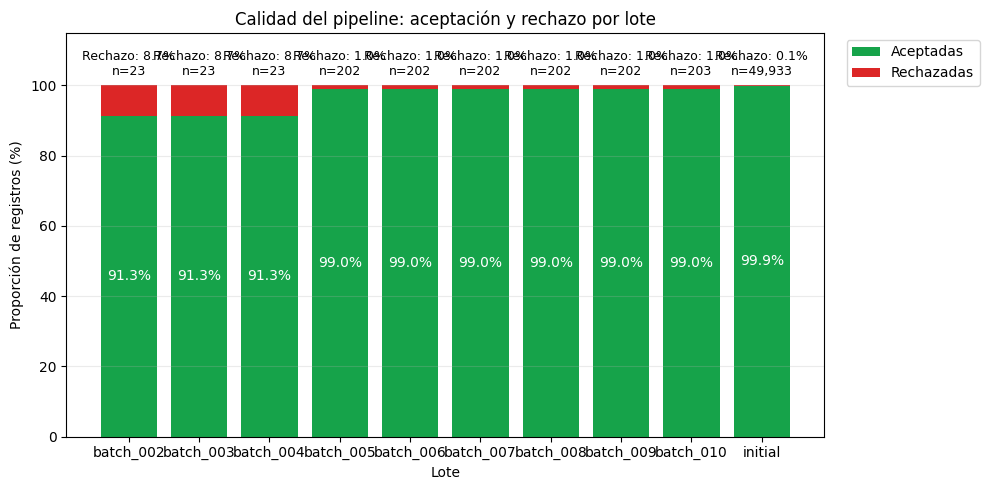

RESULTADOS POR LOTE
batch_002: 21 aceptadas (91.30%) y 2 rechazadas (8.70%). Total: 23.
batch_003: 21 aceptadas (91.30%) y 2 rechazadas (8.70%). Total: 23.
batch_004: 21 aceptadas (91.30%) y 2 rechazadas (8.70%). Total: 23.
batch_005: 200 aceptadas (99.01%) y 2 rechazadas (0.99%). Total: 202.
batch_006: 200 aceptadas (99.01%) y 2 rechazadas (0.99%). Total: 202.
batch_007: 200 aceptadas (99.01%) y 2 rechazadas (0.99%). Total: 202.
batch_008: 200 aceptadas (99.01%) y 2 rechazadas (0.99%). Total: 202.
batch_009: 200 aceptadas (99.01%) y 2 rechazadas (0.99%). Total: 202.
batch_010: 201 aceptadas (99.01%) y 2 rechazadas (0.99%). Total: 203.
initial: 49,882 aceptadas (99.90%) y 51 rechazadas (0.10%). Total: 49,933.

COMPARACIÓN
No se encontraron ambos lotes seleccionados. Revisá initial_batch_id y new_batch_id con los nombres que aparecen en la tabla. Si el lote inicial no está incluido en Gold, no puede compararse con esta fuente.

LIMITACIONES: los porcentajes permiten comparar lotes de di

In [0]:
# Tu solución. Calculá total = accepted_transactions + rejected_transactions.
# Un gráfico de barras apiladas al 100% puede facilitar la comparación de proporciones.
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# Calcular cantidades y proporciones con Spark.
batch_quality = (
    spark.table(batch)
    .groupBy("source_batch_id")
    .agg(
        F.sum("accepted_transactions").alias("aceptadas"),
        F.sum("rejected_transactions").alias("rechazadas")
    )
    .withColumn("total", F.col("aceptadas") + F.col("rechazadas"))
    .withColumn(
        "aceptadas_pct",
        F.when(F.col("total") > 0, 100.0 * F.col("aceptadas") / F.col("total"))
    )
    .withColumn(
        "rechazadas_pct",
        F.when(F.col("total") > 0, 100.0 * F.col("rechazadas") / F.col("total"))
    )
    .orderBy("source_batch_id")
)

display(batch_quality)

# Convertir sólo el resumen a Pandas.
plot_data = batch_quality.where(F.col("total") > 0).toPandas()
assert not plot_data.empty, "No hay lotes con registros para comparar."

labels = plot_data["source_batch_id"].fillna("Sin lote").astype(str)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    labels, plot_data["aceptadas_pct"],
    label="Aceptadas", color="#16a34a"
)
ax.bar(
    labels, plot_data["rechazadas_pct"],
    bottom=plot_data["aceptadas_pct"],
    label="Rechazadas", color="#dc2626"
)

for i, row in plot_data.iterrows():
    accepted_pct = float(row["aceptadas_pct"])
    rejected_pct = float(row["rechazadas_pct"])

    ax.text(
        i, accepted_pct / 2,
        f"{accepted_pct:.1f}%",
        ha="center", va="center", color="white"
    )
    ax.text(
        i, 102,
        f"Rechazo: {rejected_pct:.1f}%\nn={int(row['total']):,}",
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("Calidad del pipeline: aceptación y rechazo por lote")
ax.set_xlabel("Lote")
ax.set_ylabel("Proporción de registros (%)")
ax.set_ylim(0, 115)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

print("RESULTADOS POR LOTE")
for _, row in plot_data.iterrows():
    print(
        f"{row['source_batch_id']}: "
        f"{int(row['aceptadas']):,} aceptadas "
        f"({row['aceptadas_pct']:.2f}%) y "
        f"{int(row['rechazadas']):,} rechazadas "
        f"({row['rechazadas_pct']:.2f}%). "
        f"Total: {int(row['total']):,}."
    )

# Completar con los identificadores reales del resumen.
initial_batch_id = "batch_001"
new_batch_id = "batch_003"  # Usar "batch_002" si ése es el lote nuevo.

initial = plot_data[
    plot_data["source_batch_id"] == initial_batch_id
]
new = plot_data[
    plot_data["source_batch_id"] == new_batch_id
]

print("\nCOMPARACIÓN")
if initial.empty or new.empty:
    print(
        "No se encontraron ambos lotes seleccionados. "
        "Revisá initial_batch_id y new_batch_id con los nombres "
        "que aparecen en la tabla. Si el lote inicial no está "
        "incluido en Gold, no puede compararse con esta fuente."
    )
else:
    initial_rate = float(initial.iloc[0]["rechazadas_pct"])
    new_rate = float(new.iloc[0]["rechazadas_pct"])
    difference = new_rate - initial_rate

    print(
        f"Rechazo inicial ({initial_batch_id}): {initial_rate:.2f}%. "
        f"Rechazo nuevo ({new_batch_id}): {new_rate:.2f}%."
    )

    if abs(difference) < 1e-9:
        print("Ambos lotes presentan la misma proporción de rechazo.")
    elif difference > 0:
        print(
            f"El lote nuevo presenta {difference:.2f} puntos "
            "porcentuales más de rechazo: menor aceptación "
            "bajo las reglas de calidad del pipeline."
        )
    else:
        print(
            f"El lote nuevo presenta {abs(difference):.2f} puntos "
            "porcentuales menos de rechazo: mayor aceptación "
            "bajo las reglas de calidad del pipeline."
        )

print(
    "\nLIMITACIONES: los porcentajes permiten comparar lotes de "
    "distintos tamaños, pero en lotes pequeños unos pocos rechazos "
    "pueden cambiar mucho la tasa. La comparación presupone las "
    "mismas reglas de validación. Además, una mayor aceptación no "
    "garantiza que todos los datos sean correctos; si el generador "
    "introduce errores deliberadamente, el rechazo refleja esa prueba."
)


## Criterios de entrega

Para cada consigna entregá: (1) la transformación de datos, (2) un gráfico, y (3) una conclusión de dos o tres oraciones que responda explícitamente la pregunta.

Cada gráfico debe tener título informativo, ejes y unidades legibles, categorías ordenadas cuando corresponda y una elección de color que no sea la única forma de comunicar el significado. No conviertas una tabla Silver completa a Pandas: agregá primero con Spark y convertí sólo el resultado pequeño.